In [2]:
import os
os.environ['BOKEH_ALLOW_WS_ORIGIN'] = ("1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g")
print("BOKEH_ALLOW_WS_ORIGIN =", os.environ.get('BOKEH_ALLOW_WS_ORIGIN'))

from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS

import photutils
from photutils.psf import fit_2dgaussian
from photutils.centroids import centroid_2dg
from photutils.aperture import aperture_photometry, CircularAperture, CircularAnnulus
from astroquery.jplhorizons import Horizons


import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import numpy as np

from bokeh.io import show, output_notebook
from scipy.optimize import minimize_scalar
output_notebook()



import sys
sys.path.insert(0, 'C:/Users/Matylda/Documents/TGP')
from photometryExercise import standardPlot

BOKEH_ALLOW_WS_ORIGIN = 1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g


Loading BokehJS ...

In [3]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = True
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['figure.dpi'] = 130

In [4]:
def snr(data, ap, an):

    phot = aperture_photometry(data, ap)
    flux_ap = phot['aperture_sum'][0]

    annulus_masks = an.to_mask(method='center')
    annulus_data = annulus_masks.multiply(data)
    sky_pixels = annulus_data[annulus_masks.data > 0]
    sky_mean = np.mean(sky_pixels)
    sky_std  = np.std(sky_pixels)

    n_pix = ap.area
    flux = flux_ap - sky_mean * n_pix

    gain = 1.39
    flux_e = flux * gain
    sigma_sky_e = sky_std * gain

    sigma_flux = np.sqrt(flux_e + n_pix * sigma_sky_e**2)

    return flux/sigma_flux

In [5]:
# reading in reduced data

direc = 'C:/Users/Matylda/Documents/TGP'


a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


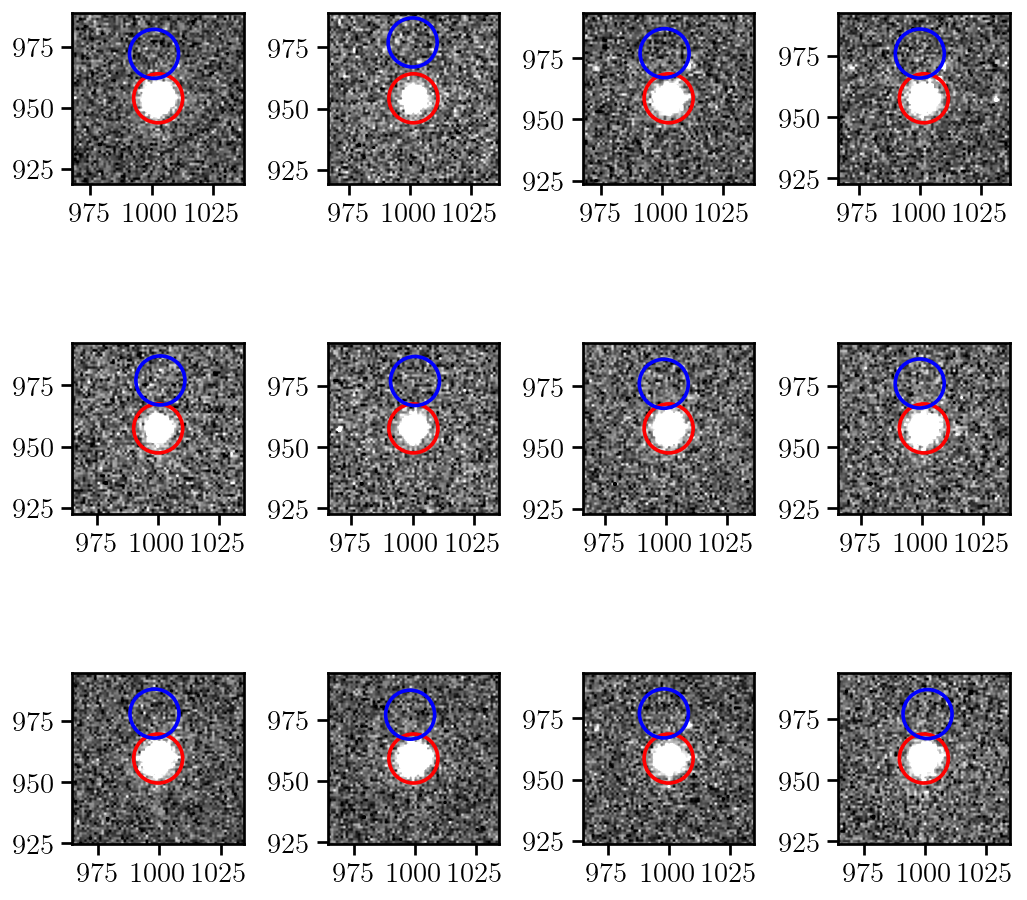

a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


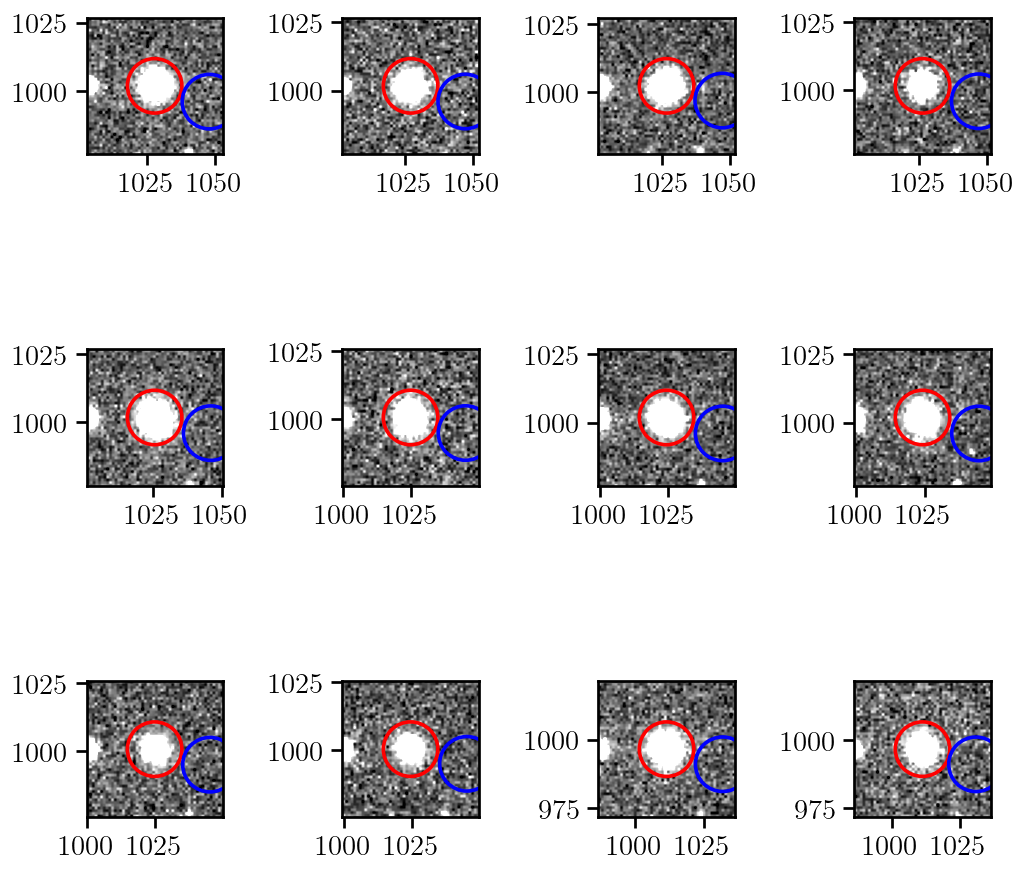

a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


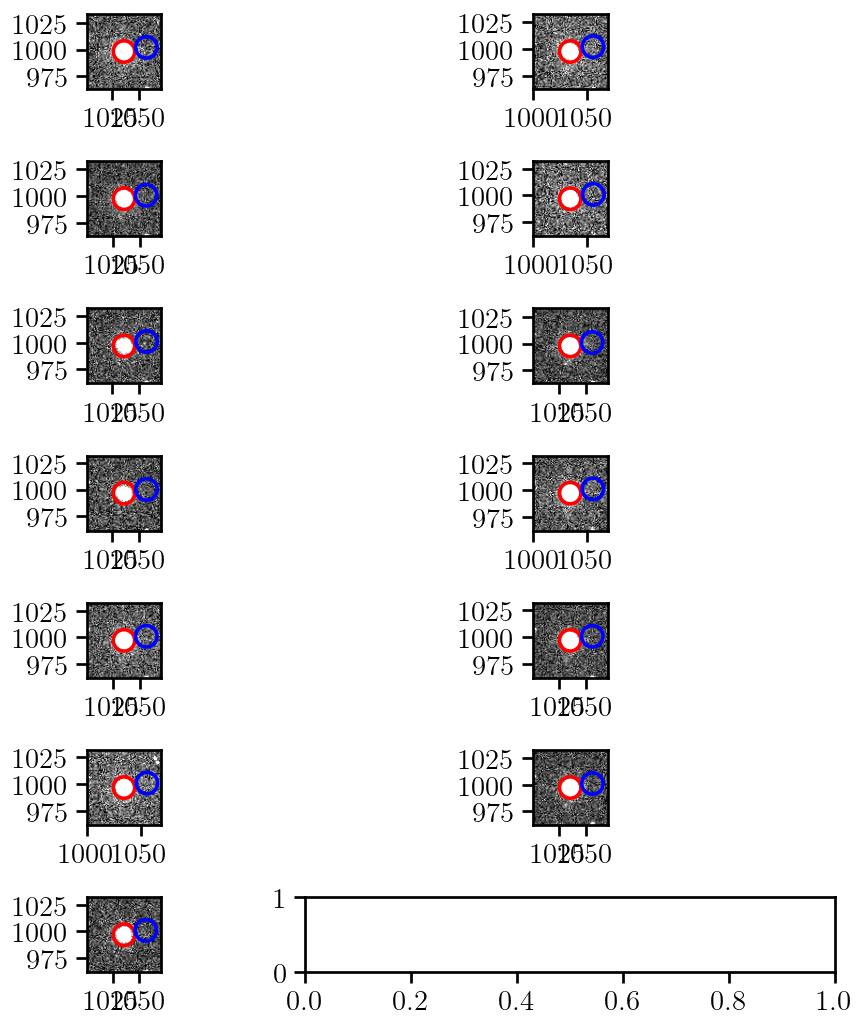

In [6]:
# Find peaks in brightnesses corresponding to the standard star locations

codes1 = [i for i in [167861, 167863, 167866, 167868, 167869, 167870, 167871, 167872, 167874, 167875, 167876, 167877]] # SS 1
codes2 = [i for i in [167879, 167880, 167881, 167882, 167885, 167886, 167887, 167888, 167889, 167890, 167905, 167906]] # SS 2
codes3 = [i for i in [167891, 167892, 167893, 167894, 167895, 167896, 167897, 167899, 167900, 167901, 167902, 167903, 167904]] # SS 3

data1 = []
data2 = []
data3 = []

locs_app1 = []
locs_app2 = []
locs_app3 = []


# Lists storing the fits
hdrs1 = [] 
hdrs2 = []
hdrs3 = []

############ STANDARD STAR 1 ################

# Need to define a reference header for missing ss1 headers
# Assuming same wcs approx for all ss1

with fits.open(direc + '/Reduced_data_day3/167866.fits') as ref: # random ss1 image filter i
    ref_hdr = ref[0].header.copy()
    ref_wcs = WCS(ref_hdr)


fig, axs = plt.subplots(3, 4, figsize=(8, 8))
i = 1
for a, c in zip(axs.flatten(), codes1):
    # try:
    with fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits') as file:
    
        # print(hdr)
        hdr = file[0].header.copy()

        # If CRPIX is missing, copy WCS from reference
        if 'CRPIX1' not in hdr or 'CRPIX2' not in hdr:
            hdr.update(ref_wcs.to_header())


        ra = (20 + 30 / 60 + 3 / 3600)*15
        dec = (39 + 15 / 60 + 21 / 3600)

        # correct for cropping the raw data
        hdr['CRPIX1'] -= 21
        hdr['CRPIX2'] -= 21
        wcs = WCS(hdr)

        px, py = wcs.world_to_pixel_values(ra, dec)
        circle = Circle((px, py), radius=10, edgecolor='red', facecolor='none', linewidth=2)

        image = file[0].data

        # vmin, vmax = np.percentile(image, [5, 99])
        # a.imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
        # a.add_patch(circle)
        # a.set_xlim(px-20, px+20)
        # a.set_ylim(py-20, py+20)

        data1.append(image)
        locs_app1.append((px, py))
        hdrs1.append(hdr)
        i+=1


r = 35

locs1 = []

for d,l,a,h in zip(data1, locs_app1, axs.flatten(), hdrs1):

    x0, y0 = int(np.round(l[0])), int(np.round(l[1]))

    cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]

    x_c, y_c = centroid_2dg(cutout)
  
    x_refined = x0 - r + x_c
    y_refined = y0 - r + y_c

    vn, vx = np.percentile(d, [5,99])
    a.imshow(d, cmap="gray", vmin=vn, vmax=vx)
    a.add_patch(Circle((x_refined, y_refined), radius=10, edgecolor="red", facecolor="none", linewidth=2))
    a.add_patch(Circle((x0, y0), radius=10, edgecolor="b", facecolor="none", linewidth=2))

    a.set_xlim(x_refined-35, x_refined+35)
    a.set_ylim(y_refined-35, y_refined+35)

    locs1.append((x_refined, y_refined))

fig.tight_layout()
plt.show()
    

############ STANDARD STAR 2 ################

# Need to define a reference header for missing ss2 headers
# Assuming same wcs approx for all ss2

with fits.open(direc + '/Reduced_data_day3/167879.fits') as ref2: # random ss2 image filter v
    ref_hdr2 = ref2[0].header.copy()
    ref_wcs2 = WCS(ref_hdr2)


fig2, axs2 = plt.subplots(3, 4, figsize=(8, 8))
i = 1
for a, c in zip(axs2.flatten(), codes2):
    # try:
    with fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits') as file:
    
        # print(hdr)
        hdr = file[0].header.copy()

        # If CRPIX is missing, copy WCS from reference
        if 'CRPIX1' not in hdr or 'CRPIX2' not in hdr:
            hdr.update(ref_wcs2.to_header())


        ra = (1 + 52 / 60 + 4.29 / 3600)*15
        dec = (47 + 1 / 60 + 47.4 / 3600)

        # correct for cropping the raw data
        hdr['CRPIX1'] -= 21
        hdr['CRPIX2'] -= 21
        wcs = WCS(hdr)

        px2, py2 = wcs.world_to_pixel_values(ra, dec)
        circle = Circle((px2, py2), radius=10, edgecolor='red', facecolor='none', linewidth=2)

        image = file[0].data

        # vmin, vmax = np.percentile(image, [5, 99])
        # a.imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
        # a.add_patch(circle)
        # a.set_xlim(px2-20, px2+20)
        # a.set_ylim(py2-20, py2+20)

        data2.append(image)
        locs_app2.append((px2, py2))
        hdrs2.append(hdr)
        i+=1


r = 25

locs2 = []

for d,l,a,h in zip(data2, locs_app2, axs2.flatten(), hdrs2):

    x0, y0 = int(np.round(l[0])), int(np.round(l[1]))

    cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]

    x_c, y_c = centroid_2dg(cutout)
  
    x_refined = x0 - r + x_c
    y_refined = y0 - r + y_c

    vn, vx = np.percentile(d, [5,99])
    a.imshow(d, cmap="gray", vmin=vn, vmax=vx)
    a.add_patch(Circle((x_refined, y_refined), radius=10, edgecolor="red", facecolor="none", linewidth=2))
    a.add_patch(Circle((x0, y0), radius=10, edgecolor="b", facecolor="none", linewidth=2))

    a.set_xlim(x_refined-25, x_refined+25)
    a.set_ylim(y_refined-25, y_refined+25)

    locs2.append((x_refined, y_refined))

fig2.tight_layout()
plt.show()


############ STANDARD STAR 3 ################

# Need to define a reference header for missing ss3 headers
# Assuming same wcs approx for all ss3

with fits.open(direc + '/Reduced_data_day3/167891.fits') as ref3: # random ss3 image filter v
    ref_hdr3 = ref3[0].header.copy()
    ref_wcs3 = WCS(ref_hdr3)


fig3, axs3 = plt.subplots(7, 2, figsize=(8, 8))
i = 1
for a, c in zip(axs3.flatten(), codes3):
    # try:
    with fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits') as file:
    
        # print(hdr)
        hdr = file[0].header.copy()

        # If CRPIX is missing, copy WCS from reference
        if 'CRPIX1' not in hdr or 'CRPIX2' not in hdr:
            hdr.update(ref_wcs3.to_header())


        ra = (3 + 44 / 60 + 7 / 3600)*15
        dec = (45 + 6 / 60 + 0.2 / 3600)

        # correct for cropping the raw data
        hdr['CRPIX1'] -= 21
        hdr['CRPIX2'] -= 21
        wcs = WCS(hdr)

        px3, py3 = wcs.world_to_pixel_values(ra, dec)
        circle = Circle((px3, py3), radius=10, edgecolor='red', facecolor='none', linewidth=2)

        image = file[0].data

        # vmin, vmax = np.percentile(image, [5, 99])
        # a.imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
        # a.add_patch(circle)

        # a.set_xlim(px3-20, px3+20)
        # a.set_ylim(py3-20, py3+20)

        data3.append(image)
        locs_app3.append((px3, py3))
        hdrs3.append(hdr)
        i+=1


r = 35

locs3 = []

for d,l,a,h in zip(data3, locs_app3, axs3.flatten(), hdrs3):

    x0, y0 = int(np.round(l[0])), int(np.round(l[1]))

    cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]

    x_c, y_c = centroid_2dg(cutout)
  
    x_refined = x0 - r + x_c
    y_refined = y0 - r + y_c

    vn, vx = np.percentile(d, [5,99])
    a.imshow(d, cmap="gray", vmin=vn, vmax=vx)
    a.add_patch(Circle((x_refined, y_refined), radius=10, edgecolor="red", facecolor="none", linewidth=2))
    a.add_patch(Circle((x0, y0), radius=10, edgecolor="b", facecolor="none", linewidth=2))

    a.set_xlim(x_refined-35, x_refined+35)
    a.set_ylim(y_refined-35, y_refined+35)

    locs3.append((x_refined, y_refined))

fig3.tight_layout()
plt.show()


In [7]:
with fits.open(direc + r'\Reduced_data_day3\167861.fits') as hdul:
    header = hdul[0].header

for key, value in header.items():
    print(f"{key} = {value}")

SIMPLE = True
BITPIX = -64
NAXIS = 2
NAXIS1 = 2006
NAXIS2 = 2006
DATE-OBS = 2025-10-22T22:23:48.5273457
END-OBS = 2025-10-22T22:24:18.6849643
EXPOSURE = 30.0
XBINNING = 2
YBINNING = 2
IMAGETYP = Object
EXPTIME = 30.0
WINDSPD = 4.62
WINDAVE = 5.31
WINDGUST = 6.35
WINDDIR = 327.2
WINDDIRA = 327.17
HUMIDITY = 21.06
AIRTEMP = 14.21
DOMETEMP = 14.28
DEVTEMP = 13.23
CLOUDBAS = 3082.5
CLOUDS = 0
ISCLOUDY = False
RAIN = 0
ISRAIN = False
OBSCODE = PIRATE
OBSLAT = 28.29924
OBSLON = -16.51021
OBSALT = 2390
INSTRUME = FLI:PL1324016
TELESCOP = CDK24
XPIXSZ = 9.0
YPIXSZ = 9.0
PXSCAL1 = 0.47
PXSCAL2 = 0.47
SCALE = 0.47
GAIN = 1.39
RDNOISE = 14.0
FULLSIZE = TRUE
FILTER = R
OBJECT = Standard_Star_1
PROGID = 362ad52b-756a-4379-8127-9d84f0986a61
PROGNAME = OSL_ROE_Asteroids_2
FOCUSPOS = 15014
EPOCH = REAL
OBSERVER = Abot
RA-REF = 20:30:03.4
DEC-REF = 39:15:21
OWNERGID = d2a75c5d-7d7a-4008-a880-a01f058c2b63
OWNERGNM = ROE User
OWNERID = d2a75c5d-7d7a-4008-a880-a01f058c2b63
OWNERNM = ROE User
ALT-REF = 0
A

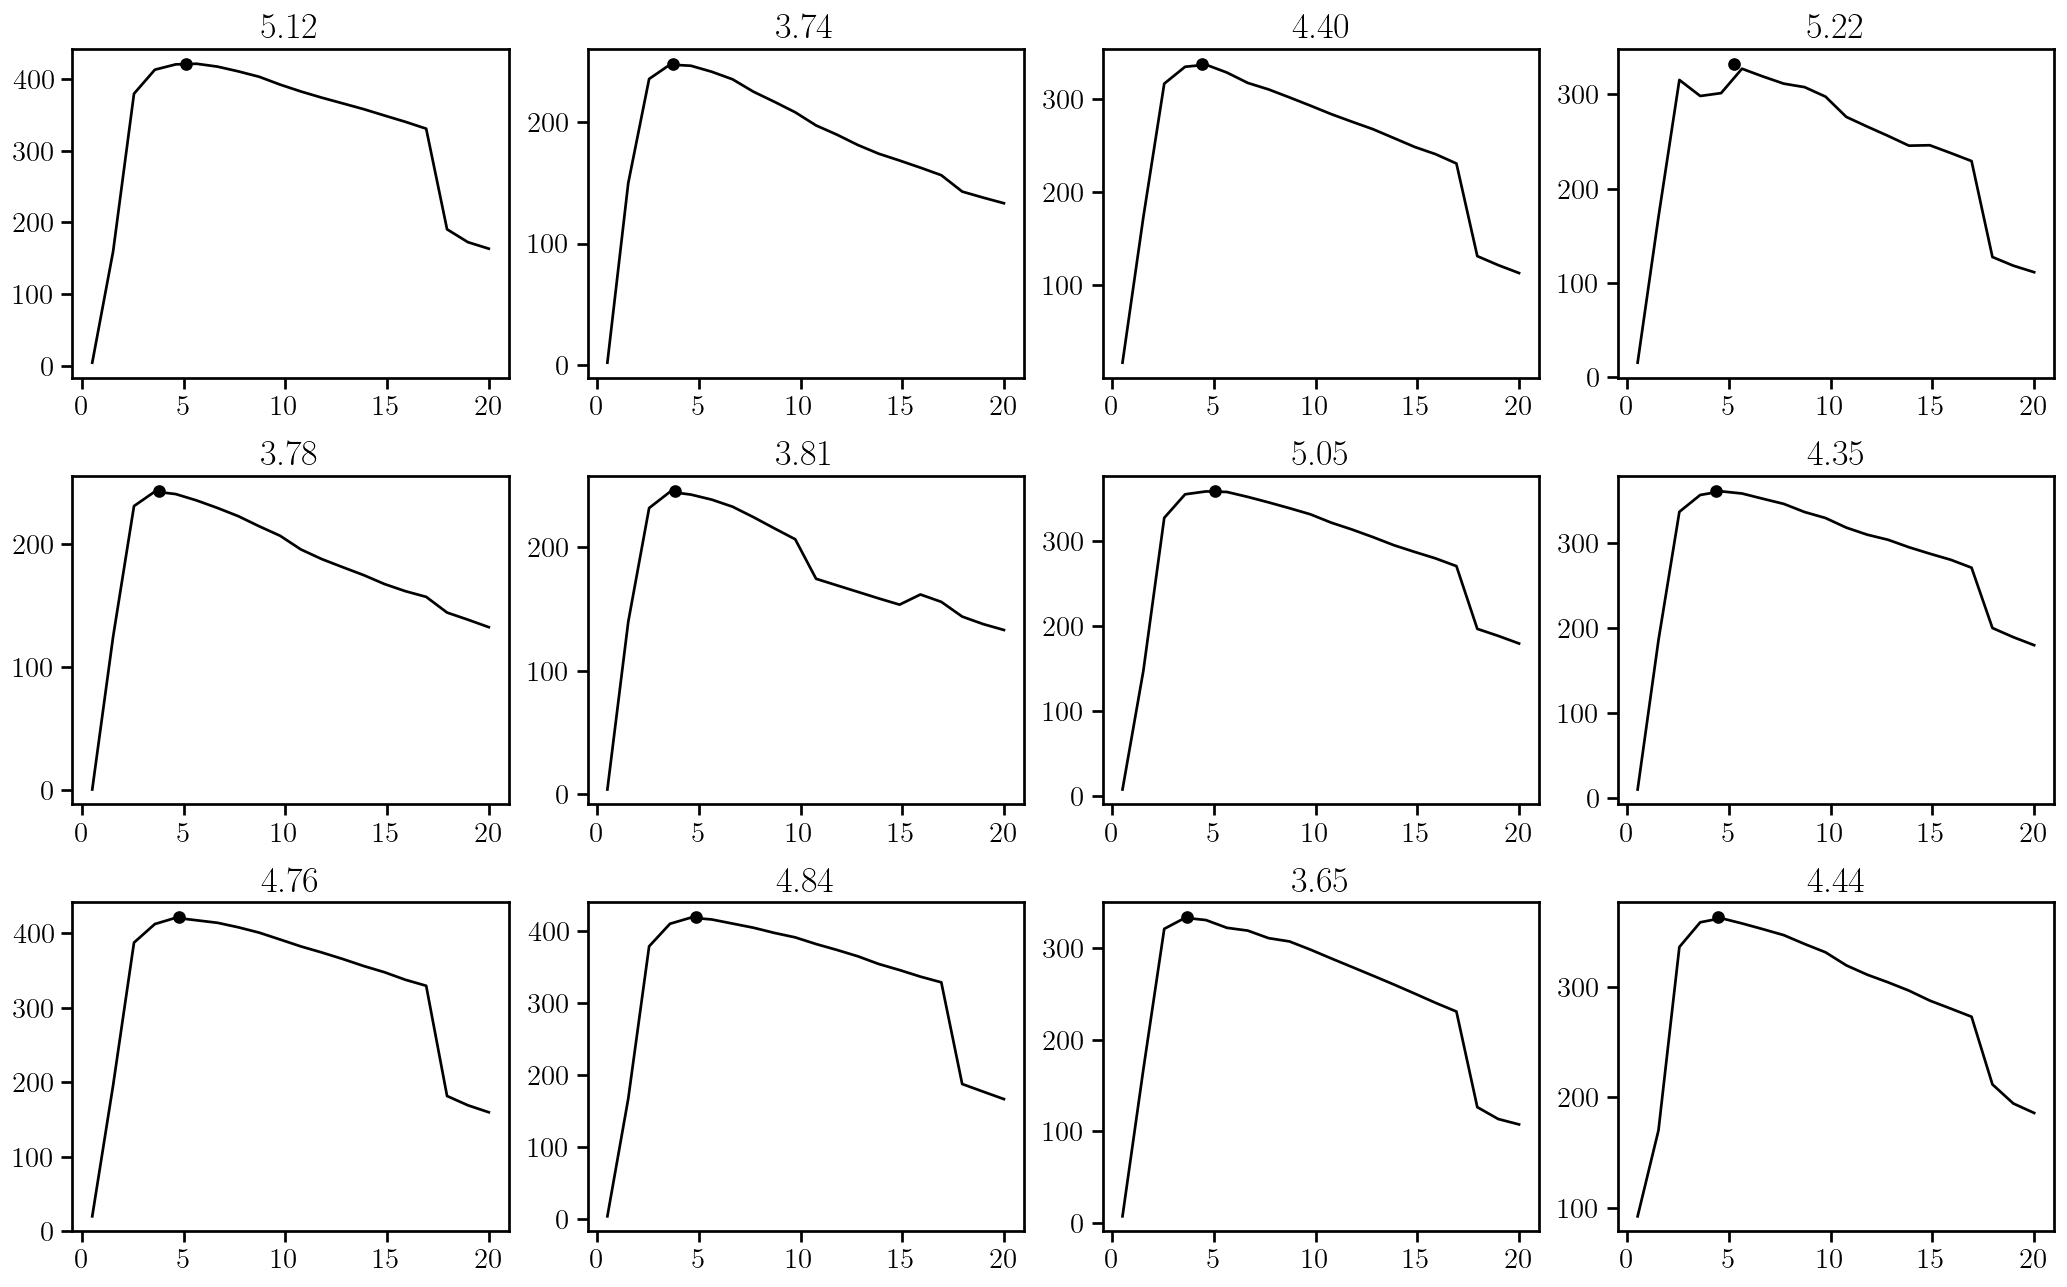

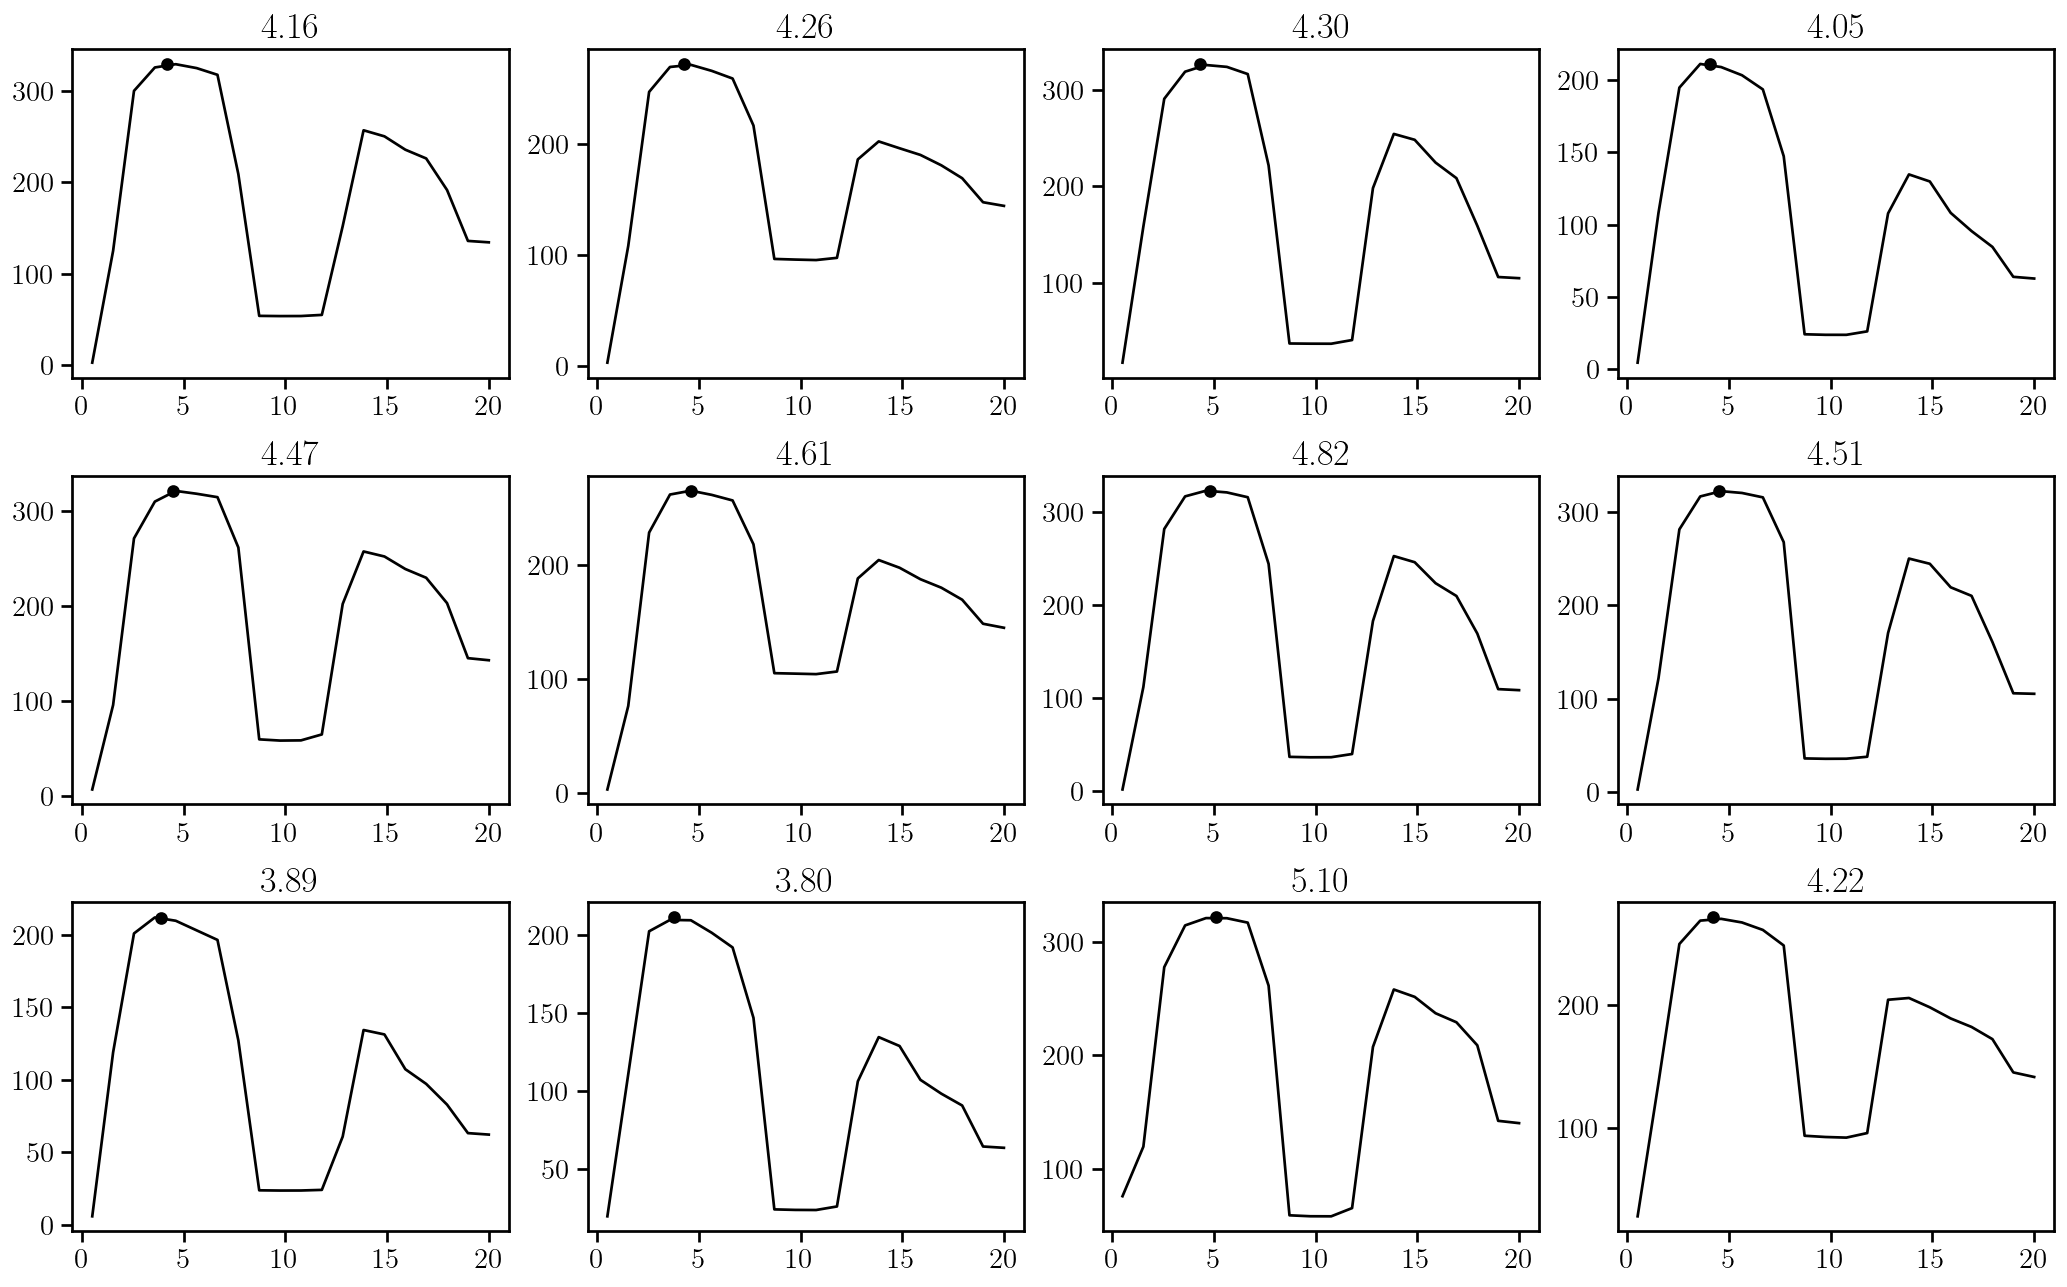

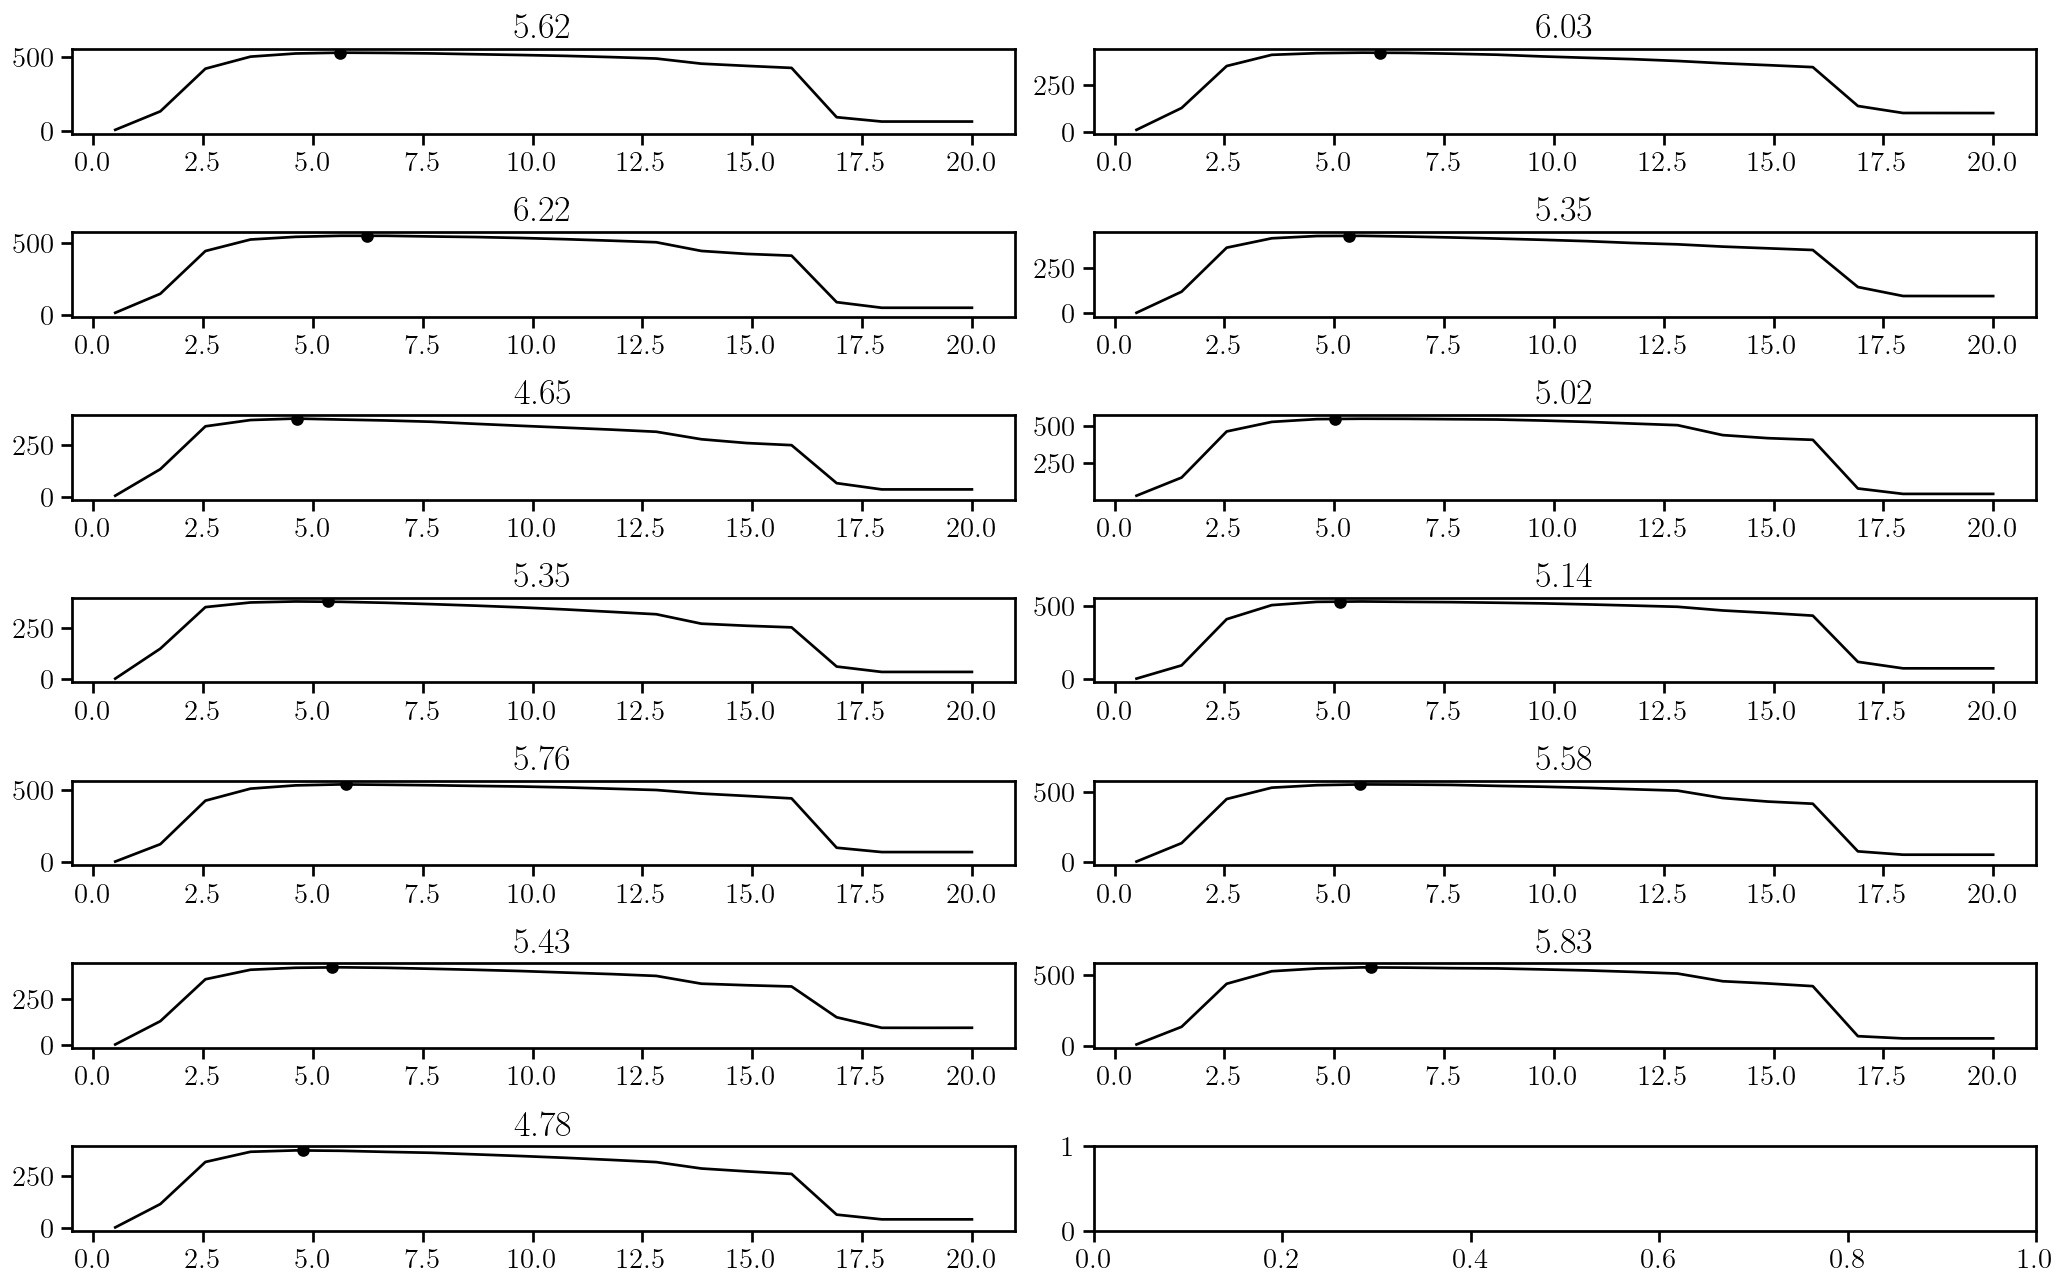

In [8]:

f,axs = plt.subplots(3, 4, figsize=(16,10))

optims = []

for d_ind,a in zip(range(len(data1)), axs.flatten()):

    def ap_opt(r):

        an1 = 2*r
        an2 = 3*r
        ap = CircularAperture((locs1[d_ind][0], locs1[d_ind][1]), r=r)
        an = CircularAnnulus((locs1[d_ind][0], locs1[d_ind][1]), r_in=an1, r_out=an2)

        return -snr(data1[d_ind], ap, an)

    aps = np.linspace(0.5, 20, 20)
    rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]

    res = minimize_scalar(ap_opt, bounds=(rough_peak-2, rough_peak+2))
   # print(f"SNR {-res.fun:.2f} at aperture {res.x:.2f} pix")
    optims.append(res.x)

   # aps = np.linspace(rough_peak-2, rough_peak+2, 200)
    a.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
    a.scatter(res.x, -res.fun, c="k")
    a.set_title(f"{res.x:.2f}")

f.tight_layout()
f2,axs2 = plt.subplots(3, 4, figsize=(16,10))

optims2 = []

for d_ind,a in zip(range(len(data2)), axs2.flatten()):

    def ap_opt(r):

        an1 = 2*r
        an2 = 3*r
        ap = CircularAperture((locs2[d_ind][0], locs2[d_ind][1]), r=r)
        an = CircularAnnulus((locs2[d_ind][0], locs2[d_ind][1]), r_in=an1, r_out=an2)

        return -snr(data2[d_ind], ap, an)

    aps = np.linspace(0.5, 20, 20)
    rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]

    res = minimize_scalar(ap_opt, bounds=(rough_peak-2, rough_peak+2))
   # print(f"SNR {-res.fun:.2f} at aperture {res.x:.2f} pix")
    optims2.append(res.x)

   # aps = np.linspace(rough_peak-2, rough_peak+2, 200)
    a.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
    a.scatter(res.x, -res.fun, c="k")
    a.set_title(f"{res.x:.2f}")

f2.tight_layout()
f3,axs3 = plt.subplots(7, 2, figsize=(16,10))

optims3 = []

for d_ind,a in zip(range(len(data3)), axs3.flatten()):
    def ap_opt(r):

        an1 = 2*r
        an2 = 3*r
        ap = CircularAperture((locs3[d_ind][0], locs3[d_ind][1]), r=r)
        an = CircularAnnulus((locs3[d_ind][0], locs3[d_ind][1]), r_in=an1, r_out=an2)

        return -snr(data3[d_ind], ap, an)

    aps = np.linspace(0.5, 20, 20)
    rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]

    res = minimize_scalar(ap_opt, bounds=(rough_peak-2, rough_peak+2))
   # print(f"SNR {-res.fun:.2f} at aperture {res.x:.2f} pix")
    optims3.append(res.x)

   # aps = np.linspace(rough_peak-2, rough_peak+2, 200)
    a.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
    a.scatter(res.x, -res.fun, c="k")
    a.set_title(f"{res.x:.2f}")

f3.tight_layout()
plt.show()



In [9]:
# have locations for images of all three standard stars 

#locs1, locs2, locs3 contain the pixel locations of the standard stars in each image

ss_1_dict = {}
ss_2_dict = {}
ss_3_dict = {}


def flux_to_mag(norm_flux):
    return -2.5 * np.log10(norm_flux)      

def error_in_mag():
    t = skyFlux + standardFlux # maybe use meanSkyValue
    C = standardFlux
    dC = np.sqrt(standardFlux + skyFlux)

    return (-2.5 / np.log(10) ) * (dC / C)   

# Let's make first an estimation of the sky values in your defined annulus
# aperture_photometry returns an astropy.table with the center of the aperture and 
# the total flux on the aperture ('aperture_sum')

for i, c in enumerate(codes1):

    rSkyInner = optims[i]*1.5
    rSkyOuter = optims[i]*2  

    apertureStandard = CircularAperture(locs1, r=optims[i])
    annulusSky = CircularAnnulus(locs1, r_in=rSkyInner, r_out=rSkyOuter)      

    file = fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits')
    hdr = file[0].header.copy()

    star = fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits')[0].data
    sky = aperture_photometry(star, annulusSky[i])
    # print(star)
    # To recover the mean sky value we should weight the total flux by the area of the annulus

    area = np.pi * rSkyOuter**2 - (np.pi * rSkyInner**2)
    skyFlux = sky['aperture_sum'].value # This is how we access astropy.table columns
    meanSkyValue = skyFlux/area

    #print(f'The mean sky value is {meanSkyValue}')

    # Once we know the mean sky value, we can perform the aperture photometry on the standard star,
    # removing first the sky value

    standard = aperture_photometry(star - meanSkyValue, apertureStandard[i])
    # print(standard)
    standardFlux = standard['aperture_sum'].value
    #print(f'Total flux on aperture for the standard star {standardFlux}')

    exposure_time = hdr['EXPOSURE']
    norm_flux = standardFlux / exposure_time

    magnitude = flux_to_mag(norm_flux)
    error_magnitude = error_in_mag()
    print(f'The magnitude of standard star 1 is {magnitude} +- {error_magnitude}')
    ss_1_dict[c] = {}
    ss_1_dict[c]['magnitude'] = magnitude
    ss_1_dict[c]['error'] = error_magnitude

    
for i, c in enumerate(codes2):
    rSkyInner = optims2[i]*1.5
    rSkyOuter = optims2[i]*2  

    apertureStandard = CircularAperture(locs2, r=optims2[i])
    annulusSky = CircularAnnulus(locs2, r_in=rSkyInner, r_out=rSkyOuter)  

    file = fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits')
    hdr = file[0].header.copy()

    star = fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits')[0].data
    sky = aperture_photometry(star, annulusSky[i])
    # print(star)
    # To recover the mean sky value we should weight the total flux by the area of the annulus

    area = np.pi * rSkyOuter**2 - (np.pi * rSkyInner**2)
    skyFlux = sky['aperture_sum'].value # This is how we access astropy.table columns
    meanSkyValue = skyFlux/area

    #print(f'The mean sky value is {meanSkyValue}')

    # Once we know the mean sky value, we can perform the aperture photometry on the standard star,
    # removing first the sky value

    standard = aperture_photometry(star - meanSkyValue, apertureStandard[i])
    # print(standard)
    standardFlux = standard['aperture_sum'].value
    #print(f'Total flux on aperture for the standard star {standardFlux}')

    exposure_time = hdr['EXPOSURE']
    norm_flux = standardFlux / exposure_time

    magnitude = flux_to_mag(norm_flux)
    error_magnitude = error_in_mag()
    print(f'The magnitude of standard star 2 is {magnitude} +- {error_magnitude}')
    ss_2_dict[c] = {}
    ss_2_dict[c]['magnitude'] = magnitude
    ss_2_dict[c]['error'] = error_magnitude


for i, c in enumerate(codes3):
    rSkyInner = optims3[i]*1.5
    rSkyOuter = optims3[i]*2  

    apertureStandard = CircularAperture(locs3, r=optims3[i])
    annulusSky = CircularAnnulus(locs3, r_in=rSkyInner, r_out=rSkyOuter)  
    file = fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits')
    hdr = file[0].header.copy()

    star = fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits')[0].data
    sky = aperture_photometry(star, annulusSky[i])
    # print(star)
    # To recover the mean sky value we should weight the total flux by the area of the annulus

    area = np.pi * rSkyOuter**2 - (np.pi * rSkyInner**2)
    skyFlux = sky['aperture_sum'].value # This is how we access astropy.table columns
    meanSkyValue = skyFlux/area

    #print(f'The mean sky value is {meanSkyValue}')

    # Once we know the mean sky value, we can perform the aperture photometry on the standard star,
    # removing first the sky value

    standard = aperture_photometry(star - meanSkyValue, apertureStandard[i])
    # print(standard)
    standardFlux = standard['aperture_sum'].value
    #print(f'Total flux on aperture for the standard star {standardFlux}')

    exposure_time = hdr['EXPOSURE']
    norm_flux = standardFlux / exposure_time

    magnitude = flux_to_mag(norm_flux)
    error_magnitude = error_in_mag()
    print(f'The magnitude of standard star 3 is {magnitude} +- {error_magnitude}')
    ss_3_dict[c] = {}
    ss_3_dict[c]['magnitude'] = magnitude
    ss_3_dict[c]['error'] = error_magnitude

The magnitude of standard star 1 is [-9.86010548] +- [-0.00215332]
The magnitude of standard star 1 is [-8.72409616] +- [-0.00361853]
The magnitude of standard star 1 is [-9.40671211] +- [-0.00268623]
The magnitude of standard star 1 is [-9.43341332] +- [-0.00267449]
The magnitude of standard star 1 is [-8.70716836] +- [-0.0036513]
The magnitude of standard star 1 is [-8.71372891] +- [-0.00364068]
The magnitude of standard star 1 is [-9.53781507] +- [-0.00249404]
The magnitude of standard star 1 is [-9.53024566] +- [-0.00250008]
The magnitude of standard star 1 is [-9.85258371] +- [-0.0021633]
The magnitude of standard star 1 is [-9.85083449] +- [-0.00216429]
The magnitude of standard star 1 is [-9.38445541] +- [-0.00270186]
The magnitude of standard star 1 is [-9.53345895] +- [-0.00249485]
The magnitude of standard star 2 is [-9.31948669] +- [-0.00275944]
The magnitude of standard star 2 is [-8.93573848] +- [-0.0032831]
The magnitude of standard star 2 is [-9.32653727] +- [-0.0027689]

a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


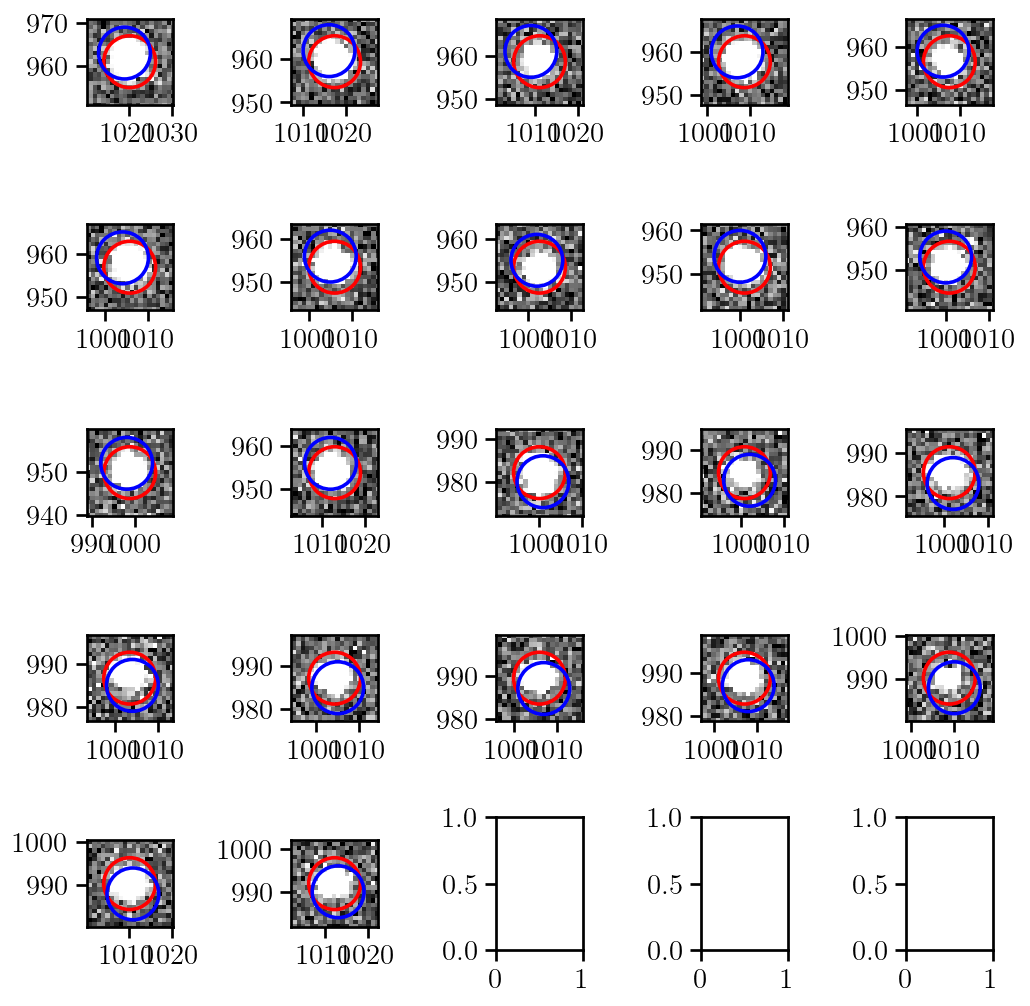

In [10]:
# REPEAT ALL FOR ASTEROID DATA

# asteroid_codes_1 = [167137]
# # ra = 23 06 17.9 dec = -14 35 31.7

# asteroid_codes_2 = [167140, 167147, 167148, 167149, 167150, 167152, 167153]
# # ra = 23 06 17.7 dec = -14 35 30.3

# asteroid_codes_3 = [167154, 167155, 167156, 167158, 167159, 167160, 167161, 167162, 167163, 167164, 167165, 167166, 167167, 167168]
# # ra = 23 06 17.3 dec = -14 35 25.1


asteroid_codes = [167137, 167140, 167147, 167148, 167149, 167150, 167152, 167153, 167154, 167155, 167156, 167158, 167159, 167160, 167161, 167162, 167163, 167164, 167165, 167166, 167167, 167168]

data = []
locs_app = []
hdrs = []

fig, axs = plt.subplots(5, 5, figsize=(8, 8))
i = 1
for a, c in zip(axs.flatten(), asteroid_codes):
    if c in [167153, 167162, 167168]:
        with fits.open(direc + '/Reduced_data_I/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()

            obj = Horizons(id="Belgica", location="Z63", epochs=Time(hdr["DATE-OBS"], format="isot", scale="utc").jd)
            eph = obj.ephemerides()
            ra = eph["RA"][0]
            dec = eph["DEC"][0]

            # correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)

            px, py = wcs.world_to_pixel_values(ra, dec)
            circle = Circle((px, py), radius=10, edgecolor='red', facecolor='none', linewidth=2)

            image = file[0].data

            data.append(image)
            locs_app.append((px, py))
            hdrs.append(hdr)
            i+=1
    else:
        with fits.open(direc + '/Reduced_data_day2/' + str(c) + '.fits') as file:
        
            hdr = file[0].header.copy()

            obj = Horizons(id="Belgica", location="Z63", epochs=Time(hdr["DATE-OBS"], format="isot", scale="utc").jd)
            eph = obj.ephemerides()
            ra = eph["RA"][0]
            dec = eph["DEC"][0]

            # correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)

            px, py = wcs.world_to_pixel_values(ra, dec)
            circle = Circle((px, py), radius=10, edgecolor='red', facecolor='none', linewidth=2)

            image = file[0].data

            data.append(image)
            locs_app.append((px, py))
            hdrs.append(hdr)
            i+=1


r = 10

locs = []

for d,l,a,h in zip(data, locs_app, axs.flatten(), hdrs):

    x0, y0 = int(np.round(l[0])), int(np.round(l[1]))

    cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]

    x_c, y_c = centroid_2dg(cutout)
  
    x_refined = x0 - r + x_c
    y_refined = y0 - r + y_c

    vn, vx = np.percentile(d, [5,99])
    a.imshow(d, cmap="gray", vmin=vn, vmax=vx)
    a.add_patch(Circle((x_refined, y_refined), radius=6, edgecolor="red", facecolor="none", linewidth=2))
    a.add_patch(Circle((x0, y0), radius=6, edgecolor="b", facecolor="none", linewidth=2))

    a.set_xlim(x_refined-10, x_refined+10)
    a.set_ylim(y_refined-10, y_refined+10)
    locs.append((x_refined, y_refined))

fig.tight_layout()
plt.show()



c:\Users\Matylda\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Matylda\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Matylda\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Matylda\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Matylda\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Matylda\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._me

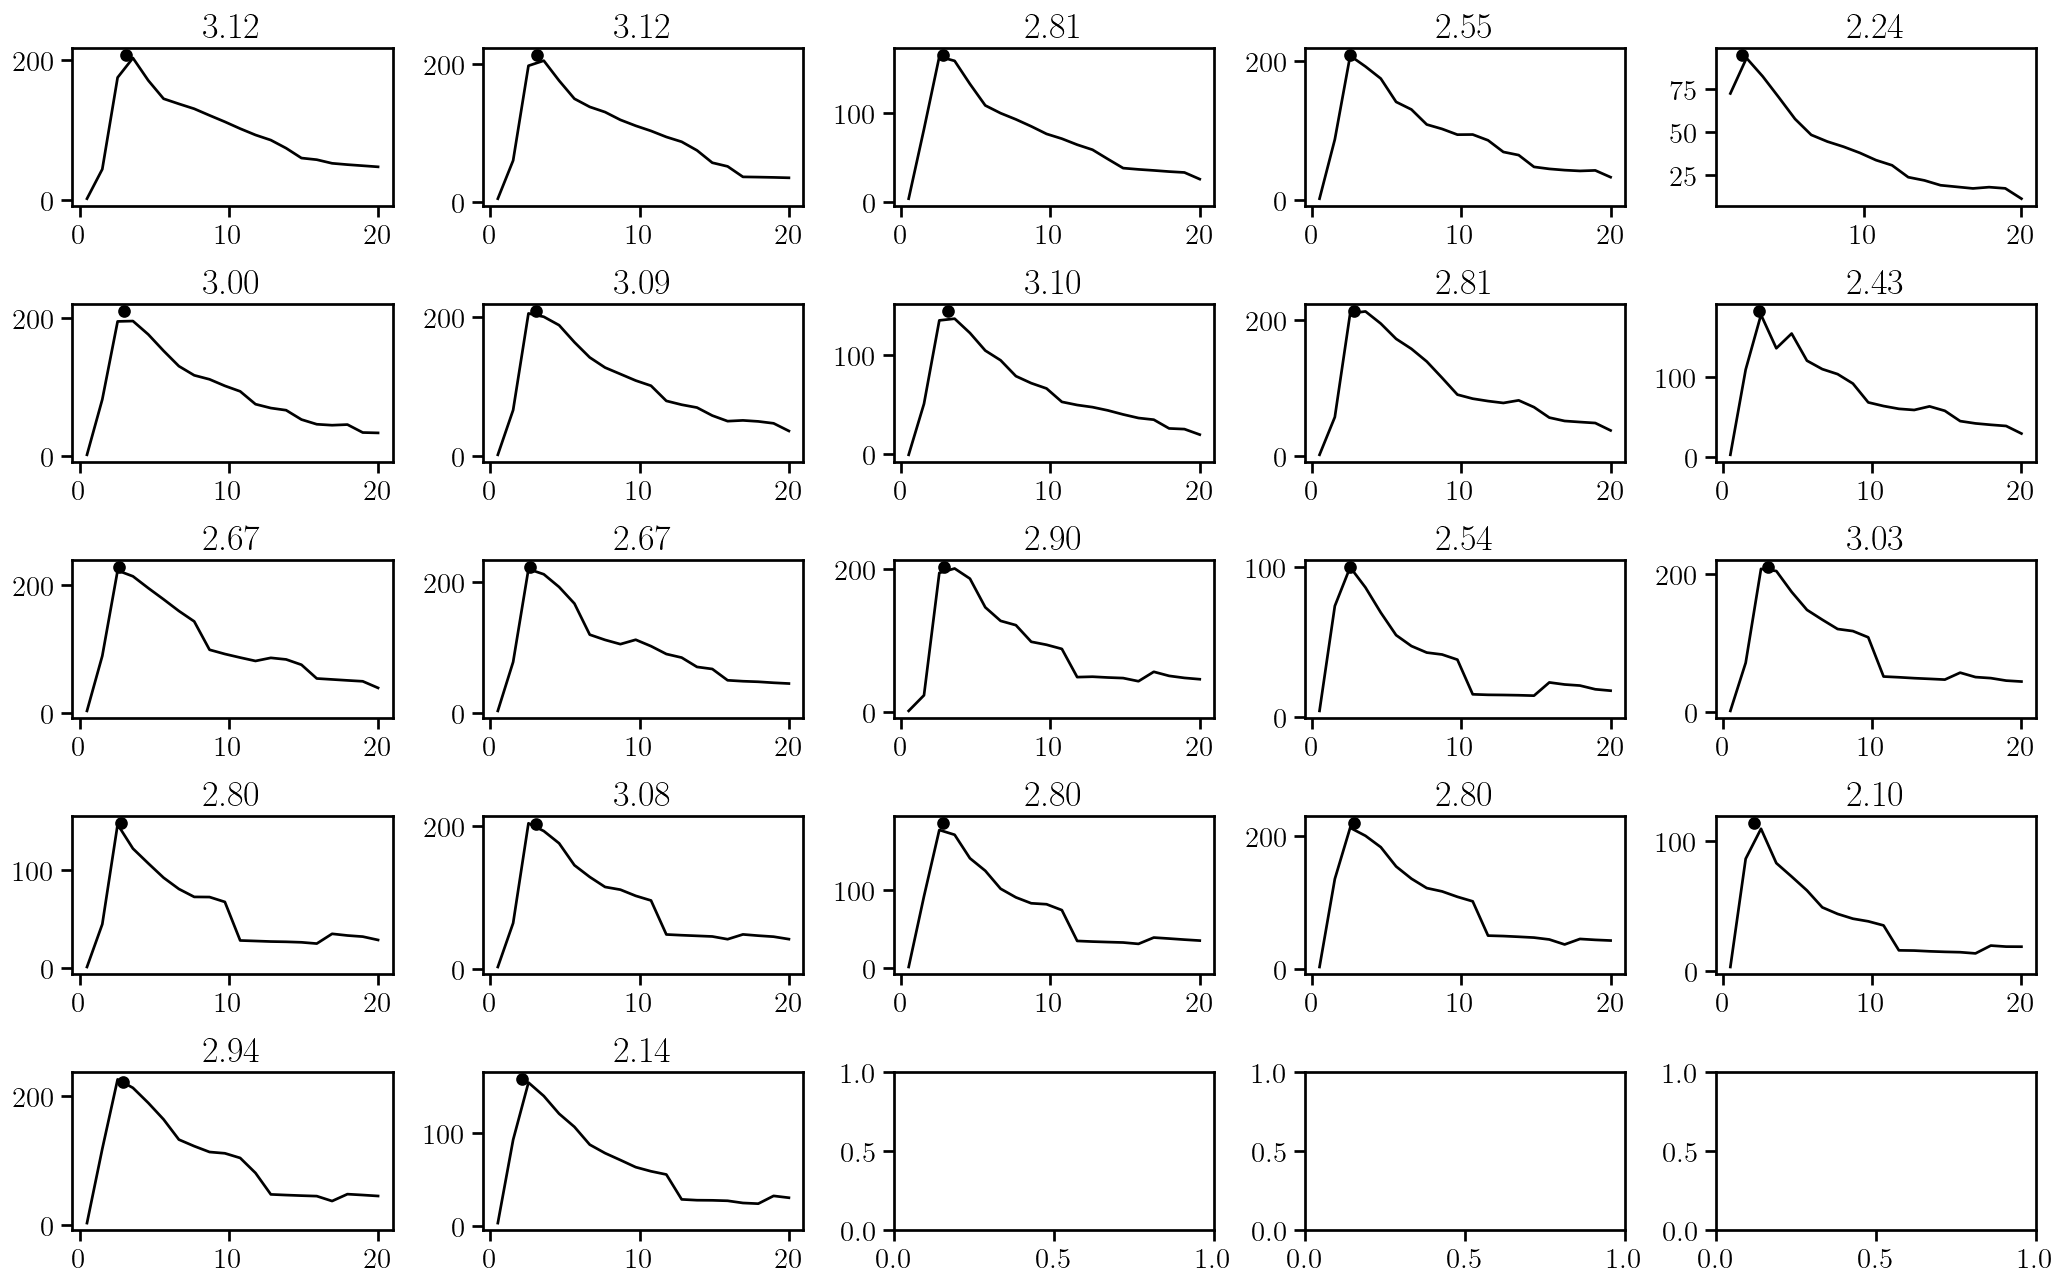

In [11]:
f,axs = plt.subplots(5, 5, figsize=(16,10))

optims_a = []

for d_ind,a in zip(range(len(data)), axs.flatten()):

    def ap_opt(r):

        an1 = 2*r
        an2 = 3*r
        ap = CircularAperture((locs[d_ind][0], locs[d_ind][1]), r=r)
        an = CircularAnnulus((locs[d_ind][0], locs[d_ind][1]), r_in=an1, r_out=an2)

        return -snr(data[d_ind], ap, an)

    aps = np.linspace(0.5, 20, 20)
    rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]

    res = minimize_scalar(ap_opt, bounds=(rough_peak-2 if rough_peak>2 else 0.1, rough_peak+2))
   # print(f"SNR {-res.fun:.2f} at aperture {res.x:.2f} pix")
    optims_a.append(res.x)

   # aps = np.linspace(rough_peak-2, rough_peak+2, 200)
    a.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
    a.scatter(res.x, -res.fun, c="k")
    a.set_title(f"{res.x:.2f}")

f.tight_layout()

In [12]:
asteroid_dict = {}

for i, c in enumerate(asteroid_codes):
    if c in [167153, 167162, 167168]:
        star = fits.open(direc + '/Reduced_data_I\\' + str(c) + '.fits')[0].data
        file = fits.open(direc + '/Reduced_data_I/' + str(c) + '.fits')
    else:
        star = fits.open(direc + '/Reduced_data_day2/' + str(c) + '.fits')[0].data
        file = fits.open(direc + '/Reduced_data_day2\\' + str(c) + '.fits')

    
    rSkyInner = optims_a[i]*1.5
    rSkyOuter = optims_a[i]*2

    apertureStandard = CircularAperture(locs, r=optims_a[i])
    annulusSky = CircularAnnulus(locs, r_in=rSkyInner, r_out=rSkyOuter)

    hdr = file[0].header.copy()
    sky = aperture_photometry(star, annulusSky[i])
    # print(star)
    # To recover the mean sky value we should weight the total flux by the area of the annulus

    area = np.pi * rSkyOuter**2 - (np.pi * rSkyInner**2)
    skyFlux = sky['aperture_sum'].value # This is how we access astropy.table columns
    meanSkyValue = skyFlux/area

    #print(f'The mean sky value is {meanSkyValue}')

    # Once we know the mean sky value, we can perform the aperture photometry on the standard star,
    # removing first the sky value

    standard = aperture_photometry(star - meanSkyValue, apertureStandard[i])
    # print(standard)
    standardFlux = standard['aperture_sum'].value
    #print(f'Total flux on aperture for the standard star {standardFlux}')

    exposure_time = hdr['EXPOSURE']
    norm_flux = standardFlux / exposure_time

    magnitude = flux_to_mag(norm_flux)
    error_magnitude = error_in_mag()
    print(f'The magnitude of asteroid is {magnitude} +- {error_magnitude}')
    asteroid_dict[c] = {}
    asteroid_dict[c]['magnitude'] = magnitude
    asteroid_dict[c]['error'] = error_magnitude

The magnitude of asteroid is [-6.46624023] +- [-0.00421152]
The magnitude of asteroid is [-6.5246369] +- [-0.00407287]
The magnitude of asteroid is [-6.07900953] +- [-0.00482617]
The magnitude of asteroid is [-6.35686292] +- [-0.00431023]
The magnitude of asteroid is [-4.97540042] +- [-0.00788282]
The magnitude of asteroid is [-6.46406794] +- [-0.00417585]
The magnitude of asteroid is [-6.54706575] +- [-0.0039961]
The magnitude of asteroid is [-6.02814036] +- [-0.00563151]
The magnitude of asteroid is [-6.54294242] +- [-0.00393744]
The magnitude of asteroid is [-6.14352193] +- [-0.00456385]
The magnitude of asteroid is [-6.55917654] +- [-0.00384754]
The magnitude of asteroid is [-6.52452899] +- [-0.00392023]
The magnitude of asteroid is [-6.44120842] +- [-0.00418087]
The magnitude of asteroid is [-5.15855327] +- [-0.00720569]
The magnitude of asteroid is [-6.52335487] +- [-0.00401818]
The magnitude of asteroid is [-5.90088896] +- [-0.00583395]
The magnitude of asteroid is [-6.53576329]

In [ ]:
# airmass is sec of altitude


for c in codes1:
    if c in [167866, 167868, 167876]:
        with fits.open(direc + '/Reduced_data_I/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()
            altitude = hdr['ALTITUDE']
            airmass = 1 / np.sin(np.radians(altitude)) 
            print(f'Date of observation of {c} is {hdr['DATE-OBS']}')
            #print(f'Airmass for ss_1 image {c} is {airmass}')
            ss_1_dict[c]['airmass'] = airmass
    else:
        with fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()
            altitude = hdr['ALTITUDE']
            airmass = 1 / np.sin(np.radians(altitude)) 
            #print(f'Date of observation of {c} is {hdr['DATE-OBS']}')
            print(f'Airmass for ss_1 image {c} is {airmass}')
            ss_1_dict[c]['airmass'] = airmass

for c in codes2:
    if c in [167882, 167889, 167890]:
        with fits.open(direc + '/Reduced_data_I/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()
            altitude = hdr['ALTITUDE']
            airmass = 1 / np.sin(np.radians(altitude)) 
            #print(f'Date of observation of {c} is {hdr['DATE-OBS']}')
            print(f'Airmass for ss_2 image {c} is {airmass}')
            ss_2_dict[c]['airmass'] = airmass
    else:
        with fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()
            #print(f'Date of observation of {c} is {hdr['DATE-OBS']}')
            altitude = hdr['ALTITUDE']
            airmass = 1 / np.sin(np.radians(altitude)) 
            print(f'Airmass for ss_2 image {c} is {airmass}')
            ss_2_dict[c]['airmass'] = airmass

for c in codes3:
    if c in [167895, 167897, 167904]:
        with fits.open(direc + '/Reduced_data_I/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()
            altitude = hdr['ALTITUDE']
            airmass = 1 / np.sin(np.radians(altitude)) 
            print(f'Airmass for ss_3 image {c} is {airmass}')
            ss_3_dict[c]['airmass'] = airmass
    else:
        with fits.open(direc + '/Reduced_data_day3/' + str(c) + '.fits') as file:
            hdr = file[0].header.copy()
            altitude = hdr['ALTITUDE']
            airmass = 1 / np.sin(np.radians(altitude)) 
            print(f'Airmass for ss_3 image {c} is {airmass}')
            ss_3_dict[c]['airmass'] = airmass

Date of observation of 167861 is 2025-10-22T22:23:48.5273457
Airmass for ss_1 image 167861 is 1.2565377051960789
Date of observation of 167863 is 2025-10-22T22:25:33.7605263
Airmass for ss_1 image 167863 is 1.2619432646018032
Date of observation of 167866 is 2025-10-22T22:34:17.5055918
Airmass for ss_1 image 167866 is 1.291918162190484
Date of observation of 167868 is 2025-10-22T22:38:28.5528507
Airmass for ss_1 image 167868 is 1.3073879133400947
Date of observation of 167869 is 2025-10-22T22:39:12.7516629
Airmass for ss_1 image 167869 is 1.3100877570582545
Date of observation of 167870 is 2025-10-22T22:39:45.0511591
Airmass for ss_1 image 167870 is 1.3120332606799163
Date of observation of 167871 is 2025-10-22T22:40:27.5005780
Airmass for ss_1 image 167871 is 1.3147712956096655
Date of observation of 167872 is 2025-10-22T22:40:59.8994541
Airmass for ss_1 image 167872 is 1.3167404448392903
Date of observation of 167874 is 2025-10-22T22:43:48.7383544
Airmass for ss_1 image 167874 is 1.3

sec_a = 1
sec_b = 1.5

e_i = (magnitudes[1] - magnitudes[0]) / (sec_b - sec_a)

e_v = (magnitudes[3] - magnitudes[2]) / (sec_b - sec_a)

e_i_e = np.sqrt(magnitude_errors[1]**2 + magnitude_errors[0]**2)

e_v_e = np.sqrt(magnitude_errors[3]**2 + magnitude_errors[2]**2)

print(f'e_v is {e_v}')
print(f'e_i is {e_i}')

print(f'e_v_e is {e_v_e}')
print(f'e_i_e is {e_i_e}')

In [ ]:
# so for standard star 1 i need to do pairwise extinction coefficient for each pair of images in each filter
# then average those to get final extinction coefficient per filter

magnitudes_r_1 = []
airmasses_r_1 = []
magnitudes_v_1 = []
airmasses_v_1 = []
magnitudes_b_1 = []
airmasses_b_1 = []
magnitudes_i_1 = []
airmasses_i_1 = []

for c in codes1:
    print(f'Now printing for {c}: {ss_1_dict[c]}')
    if c in [167861, 167874, 167875]:
        # r
        
        magnitudes_r_1.append(ss_1_dict[c]['magnitude'])
        airmasses_r_1.append(ss_1_dict[c]['airmass'])
    elif c in [167871, 167872, 167877]:
        # v
        magnitudes_v_1.append(ss_1_dict[c]['magnitude'])
        airmasses_v_1.append(ss_1_dict[c]['airmass'])
    elif c in [167863, 167869, 167870]:
        # b
        magnitudes_b_1.append(ss_1_dict[c]['magnitude'])
        airmasses_b_1.append(ss_1_dict[c]['airmass'])
    elif c in [167866, 167868, 167876]:
        # i
        magnitudes_i_1.append(ss_1_dict[c]['magnitude'])
        airmasses_i_1.append(ss_1_dict[c]['airmass'])
        
def extinction_coeff(mags, ams):
    """
    Calculate extinction coefficient from the slope of magnitude vs airmass.
    m = m_0 + k*X, so k = dm/dX
    """
    mags = np.array(mags)
    ams = np.array(ams)
    
    # Linear fit: mags = intercept + slope * ams
    # slope is the extinction coefficient k
    coeffs = np.polyfit(ams, mags, 1)
    k = coeffs[0]  # slope
    
    return k
    
k_r_1 = extinction_coeff(magnitudes_r_1, airmasses_r_1)
k_v_1 = extinction_coeff(magnitudes_v_1, airmasses_v_1)
k_b_1 = extinction_coeff(magnitudes_b_1, airmasses_b_1)
k_i_1 = extinction_coeff(magnitudes_i_1, airmasses_i_1)


print(f'Extinction coefficient in r band: {k_r_1}')
print(f'Extinction coefficient in v band: {k_v_1}')
print(f'Extinction coefficient in b band: {k_b_1}')
print(f'Extinction coefficient in i band: {k_i_1}')

# not right values

# zero point is m known - m instrumental - (k * airmass)

# using 1 until i can find true magnitudes for the standard stars
m_b = 1
m_v = 1
m_r = 1
m_i = 1

ZP_r_1 = m_r - np.mean(magnitudes_r_1) - k_r_1 * np.mean(airmasses_r_1)
ZP_v_1 = m_v - np.mean(magnitudes_v_1) - k_v_1 * np.mean(airmasses_v_1)
ZP_b_1 = m_b - np.mean(magnitudes_b_1) - k_b_1 * np.mean(airmasses_b_1)
ZP_i_1 = m_i - np.mean(magnitudes_i_1) - k_i_1 * np.mean(airmasses_i_1)
print(f'Zero point in r band: {ZP_r_1}')
print(f'Zero point in v band: {ZP_v_1}')
print(f'Zero point in b band: {ZP_b_1}')
print(f'Zero point in i band: {ZP_i_1}')
    

Now printing for 167861: {'magnitude': array([-9.86010548]), 'error': array([-0.00215332]), 'airmass': 1.2565377051960789}
Now printing for 167874: {'magnitude': array([-9.85258371]), 'error': array([-0.0021633]), 'airmass': 1.327550663330763}
Now printing for 167875: {'magnitude': array([-9.85083449]), 'error': array([-0.00216429]), 'airmass': 1.3295845261315726}
Extinction coefficient in r band: [0.11701231]
Extinction coefficient in v band: [0.05790471]
Extinction coefficient in b band: [0.27356622]
Extinction coefficient in i band: [0.68367304]
Zero point in r band: [10.70185859]
Zero point in v band: [10.45727351]
Zero point in b band: [9.36081488]
Zero point in i band: [9.51218372]


In [ ]:
magnitudes_r_2 = []
airmasses_r_2 = []
magnitudes_v_2 = []
airmasses_v_2 = []
magnitudes_b_2 = []
airmasses_b_2 = []
magnitudes_i_2 = []
airmasses_i_2 = []


for c in codes2:
    print(f'Now printing for {c}: {ss_1_dict[c]}')
    if c in [167881, 167887, 167888]:
        # r
        magnitudes_r_2.append(ss_2_dict[c]['magnitude'])
        airmasses_r_2.append(ss_2_dict[c]['airmass'])
    elif c in [167879, 167885, 167905]:
        # v
        magnitudes_v_2.append(ss_2_dict[c]['magnitude'])
        airmasses_v_2.append(ss_2_dict[c]['airmass'])
    elif c in [167880, 167886, 167892]:
        # b
        magnitudes_b_2.append(ss_2_dict[c]['magnitude'])
        airmasses_b_2.append(ss_2_dict[c]['airmass'])
    elif c in [167882, 167889, 167890]:
        # i
        magnitudes_i_2.append(ss_2_dict[c]['magnitude'])
        airmasses_i_2.append(ss_2_dict[c]['airmass'])

def extinction_coeff(mags, ams):
    """
    Calculate extinction coefficient from the slope of magnitude vs airmass.
    m = m_0 + k*X, so k = dm/dX
    """
    mags = np.array(mags)
    ams = np.array(ams)
    
    # Linear fit: mags = intercept + slope * ams
    # slope is the extinction coefficient k
    coeffs = np.polyfit(ams, mags, 1)
    k = coeffs[0]  # slope
    
    return k


k_r_2 = extinction_coeff(magnitudes_r_2, airmasses_r_2)
k_v_2 = extinction_coeff(magnitudes_v_2, airmasses_v_2)
k_b_2 = extinction_coeff(magnitudes_b_2, airmasses_b_2)
k_i_2 = extinction_coeff(magnitudes_i_2, airmasses_i_2)

print(magnitudes_b_2)
print(airmasses_b_2)
plt.scatter(magnitudes_b_2, airmasses_b_2)
plt.show()


print(f'Extinction coefficient in r band: {k_r_2}')
print(f'Extinction coefficient in v band: {k_v_2}')
print(f'Extinction coefficient in b band: {k_b_2}')
print(f'Extinction coefficient in i band: {k_i_2}')

# zero point is m known - m instrumental - (k * airmass)

# using 1 until i can find true magnitudes for the standard stars
m_b = 1
m_v = 1
m_r = 1
m_i = 1

ZP_r_2 = m_r - np.mean(magnitudes_r_2) - k_r_2 * np.mean(airmasses_r_2)
ZP_v_2 = m_v - np.mean(magnitudes_v_2) - k_v_2 * np.mean(airmasses_v_2)
ZP_b_2 = m_b - np.mean(magnitudes_b_2) - k_b_2 * np.mean(airmasses_b_2)
ZP_i_2 = m_i - np.mean(magnitudes_i_2) - k_i_2 * np.mean(airmasses_i_2)
print(f'Zero point in r band: {ZP_r_2}')
print(f'Zero point in v band: {ZP_v_2}')
print(f'Zero point in b band: {ZP_b_2}')
print(f'Zero point in i band: {ZP_i_2}')

IndentationError: expected an indented block after 'for' statement on line 11 (2001356754.py, line 12)

In [18]:
magnitudes_r_3 = []
airmasses_r_3 = []
magnitudes_v_3 = []
airmasses_v_3 = []
magnitudes_b_3 = []
airmasses_b_3 = []
magnitudes_i_3 = []
airmasses_i_3 = []

for c in codes3:
 
    if c in [167893, 167896, 167901]:
        # r
        magnitudes_r_3.append(ss_3_dict[c]['magnitude'])
        airmasses_r_3.append(ss_3_dict[c]['airmass'])
    elif c in [167891, 167899, 167900]:
        # v
        magnitudes_v_3.append(ss_3_dict[c]['magnitude'])
        airmasses_v_3.append(ss_3_dict[c]['airmass'])
    elif c in [167892, 167902]:
        # b
        magnitudes_b_3.append(ss_3_dict[c]['magnitude'])
        airmasses_b_3.append(ss_3_dict[c]['airmass'])
    elif c in [167894, 167895, 167897, 167904]:
        # i
        magnitudes_i_3.append(ss_3_dict[c]['magnitude'])
        airmasses_i_3.append(ss_3_dict[c]['airmass'])
        
def extinction_coeff(mags, ams):
    """
    Calculate extinction coefficient from the slope of magnitude vs airmass.
    m = m_0 + k*X, so k = dm/dX
    """
    mags = np.array(mags)
    ams = np.array(ams)
    
    # Linear fit: mags = intercept + slope * ams
    # slope is the extinction coefficient k
    coeffs = np.polyfit(ams, mags, 1)
    k = coeffs[0]  # slope
    
    return k

k_r_3 = extinction_coeff(magnitudes_r_3, airmasses_r_3)
k_v_3 = extinction_coeff(magnitudes_v_3, airmasses_v_3)
k_b_3 = extinction_coeff(magnitudes_b_3, airmasses_b_3)
k_i_3 = extinction_coeff(magnitudes_i_3, airmasses_i_3)

print(f'Extinction coefficient in r band: {k_r_3}')
print(f'Extinction coefficient in v band: {k_v_3}')
print(f'Extinction coefficient in b band: {k_b_3}')
print(f'Extinction coefficient in i band: {k_i_3}')

# not right values

# zero point is m known - m instrumental - (k * airmass)

# using 1 until i can find true magnitudes for the standard stars
m_b = 1
m_v = 1
m_r = 1
m_i = 1

ZP_r_3 = m_r - np.mean(magnitudes_r_3) - k_r_3 * np.mean(airmasses_r_3)
ZP_v_3 = m_v - np.mean(magnitudes_v_3) - k_v_3 * np.mean(airmasses_v_3)
ZP_b_3 = m_b - np.mean(magnitudes_b_3) - k_b_3 * np.mean(airmasses_b_3)
ZP_i_3 = m_i - np.mean(magnitudes_i_3) - k_i_3 * np.mean(airmasses_i_3)
print(f'Zero point in r band: {ZP_r_3}')
print(f'Zero point in v band: {ZP_v_3}')
print(f'Zero point in b band: {ZP_b_3}')
print(f'Zero point in i band: {ZP_i_3}')

Extinction coefficient in r band: [0.63140093]
Extinction coefficient in v band: [0.84084219]
Extinction coefficient in b band: [-0.2304014]
Extinction coefficient in i band: [-4.1741712]
Zero point in r band: [10.54760499]
Zero point in v band: [10.16570558]
Zero point in b band: [11.21377105]
Zero point in i band: [16.606194]
